In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("D:\Advanced Course\Final Project\Solar-Power-Production-Prediction\Data\Solar Power Plant Data.csv")

df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [7]:
df.shape

(8760, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   str    
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 547.6 KB


In [9]:
df.describe()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.639823,11.180479,1010.361781,97.538493,6.978893,76.719406,684.746071
std,1.628754,21.171295,12.793971,182.336029,7.604266,19.278996,1487.454665
min,0.000000,0.000000,965.900000,-9.300000,-12.400000,13.000000,0.000000
25%,1.400000,0.000000,1002.800000,-6.200000,0.500000,64.000000,0.000000
50%,2.300000,0.000000,1011.000000,-1.400000,6.400000,82.000000,0.000000
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000


In [10]:
df.isnull().sum()

Date-Hour(NMT)         0
WindSpeed              0
Sunshine               0
AirPressure            0
Radiation              0
AirTemperature         0
RelativeAirHumidity    0
SystemProduction       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

Date-Hour(NMT)             str
WindSpeed              float64
Sunshine                 int64
AirPressure            float64
Radiation              float64
AirTemperature         float64
RelativeAirHumidity      int64
SystemProduction       float64
dtype: object

In [18]:
df['Date-Hour(NMT)'] = pd.to_datetime(
    df['Date-Hour(NMT)'],
    format='%d.%m.%Y-%H:%M'
)
print("Start date:", df['Date-Hour(NMT)'].min())
print("End date:", df['Date-Hour(NMT)'].max())

Start date: 2017-01-01 00:00:00
End date: 2017-12-31 23:00:00


In [19]:
df['SystemProduction'].describe()

count    8760.000000
mean      684.746071
std      1487.454665
min         0.000000
25%         0.000000
50%         0.000000
75%       464.249950
max      7701.000000
Name: SystemProduction, dtype: float64

In [21]:
df['Hour'] = df['Date-Hour(NMT)'].dt.hour
hourly_production = df.groupby('Hour')['SystemProduction'].mean()

hourly_production

Hour
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.610959
6       14.721461
7       68.952967
8      178.794520
9      422.413700
10     840.154334
11    1557.572373
12    2224.448175
13    2311.710505
14    2225.524654
15    1927.086868
16    1615.669062
17    1312.181734
18     912.964038
19     547.587675
20     207.545665
21      55.798858
22      10.166438
23       0.001712
Name: SystemProduction, dtype: float64

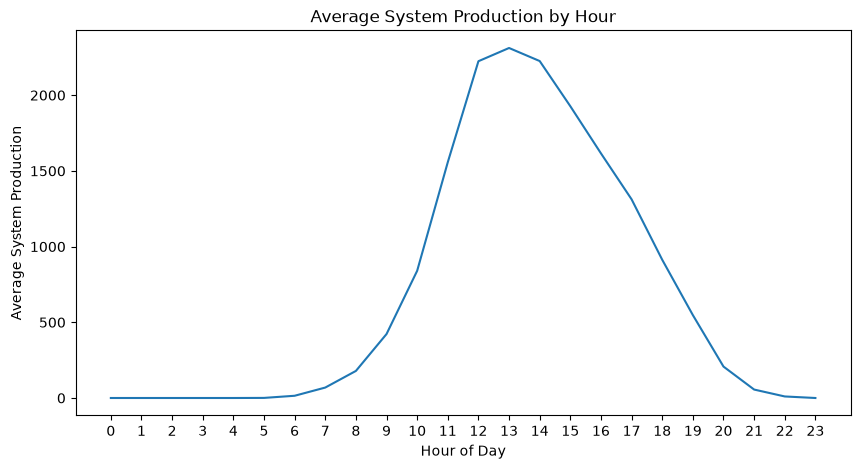

In [22]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=hourly_production.index, y=hourly_production.values)

plt.title('Average System Production by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average System Production')

plt.xticks(range(24))
plt.show()

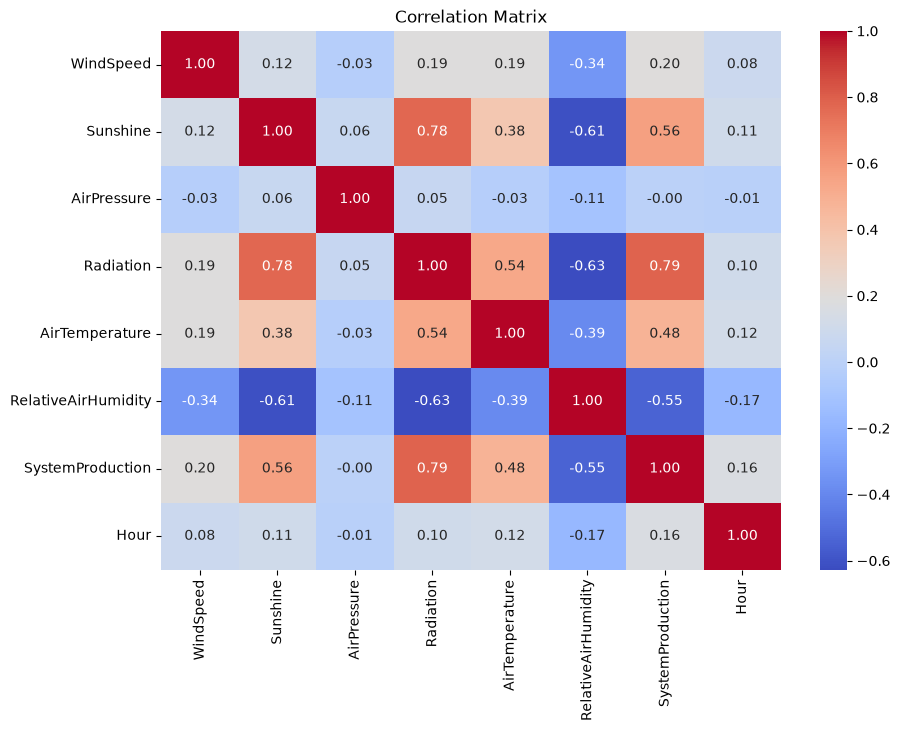

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

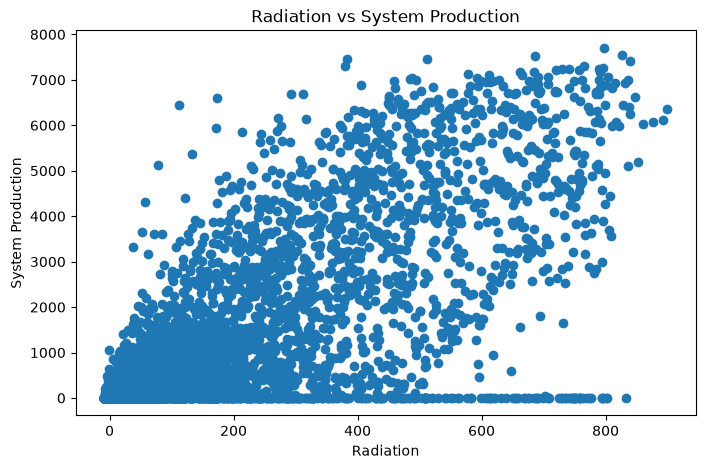

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['Radiation'], df['SystemProduction'])
plt.xlabel('Radiation')
plt.ylabel('System Production')
plt.title('Radiation vs System Production')
plt.show()

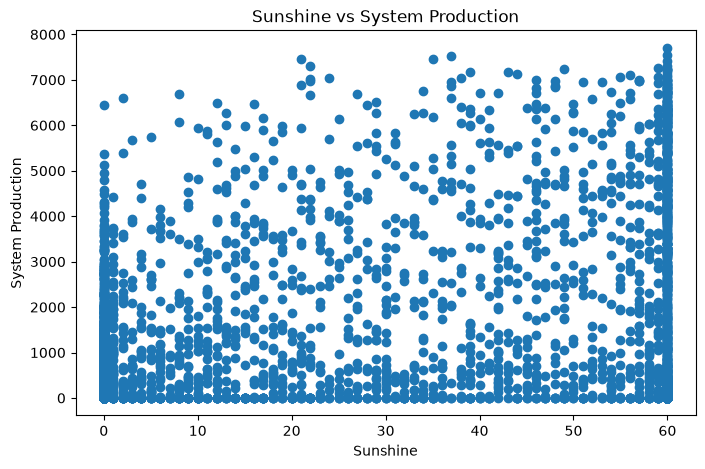

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Sunshine'], df['SystemProduction'])
plt.xlabel('Sunshine')
plt.ylabel('System Production')
plt.title('Sunshine vs System Production')
plt.show()

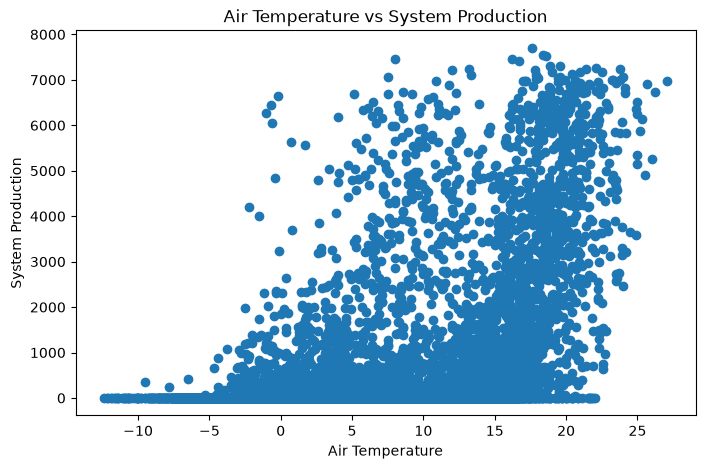

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(df['AirTemperature'], df['SystemProduction'])
plt.xlabel('Air Temperature')
plt.ylabel('System Production')
plt.title('Air Temperature vs System Production')
plt.show()

In [27]:
correlation = df.corr(numeric_only=True)

correlation['SystemProduction'].sort_values(ascending=False)

SystemProduction       1.000000
Radiation              0.785717
Sunshine               0.564228
AirTemperature         0.480407
WindSpeed              0.195650
Hour                   0.160672
AirPressure           -0.004487
RelativeAirHumidity   -0.545252
Name: SystemProduction, dtype: float64